Putu Indra Mahendra
<br>
5025221215

In [ ]:
### About DataSet ###
### LINK : https://www.kaggle.com/datasets/dannytheodore/socio-economic-of-indonesia-in-2021?resource=download
### Indonesia merupakan negara kepulauan yang terletak di Asia Tenggara. Dalam dataset ini terdapat beberapa variabel sosial-ekonomi Indonesia pada tahun 2021. ###

In [516]:
# Selalu awali dengan import-import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [517]:
# 1. importing dataset
df = pd.read_csv('archive/2021socio_economic_indonesia.csv')

In [518]:
df.head()

,province,cities_reg,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap
0,Aceh,Simeulue,18.98,2.275,65.240,9.48,7148
1,Aceh,Aceh Singkil,20.36,2.425,67.355,8.68,8776
2,Aceh,Aceh Selatan,13.18,5.531,64.360,8.88,8180
3,Aceh,Aceh Tenggara,13.41,5.063,68.155,9.67,8030
4,Aceh,Aceh Timur,14.45,10.616,68.705,8.21,8577


In [519]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   province               514 non-null    object 
 1   cities_reg             514 non-null    object 
 2   poorpeople_percentage  514 non-null    float64
 3   reg_gdp                514 non-null    float64
 4   life_exp               514 non-null    float64
 5   avg_schooltime         514 non-null    float64
 6   exp_percap             514 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 28.2+ KB


In [520]:
# dari sini data sudah tidak ada null
df.isna().sum()

province                 0
cities_reg               0
poorpeople_percentage    0
reg_gdp                  0
life_exp                 0
avg_schooltime           0
exp_percap               0
dtype: int64

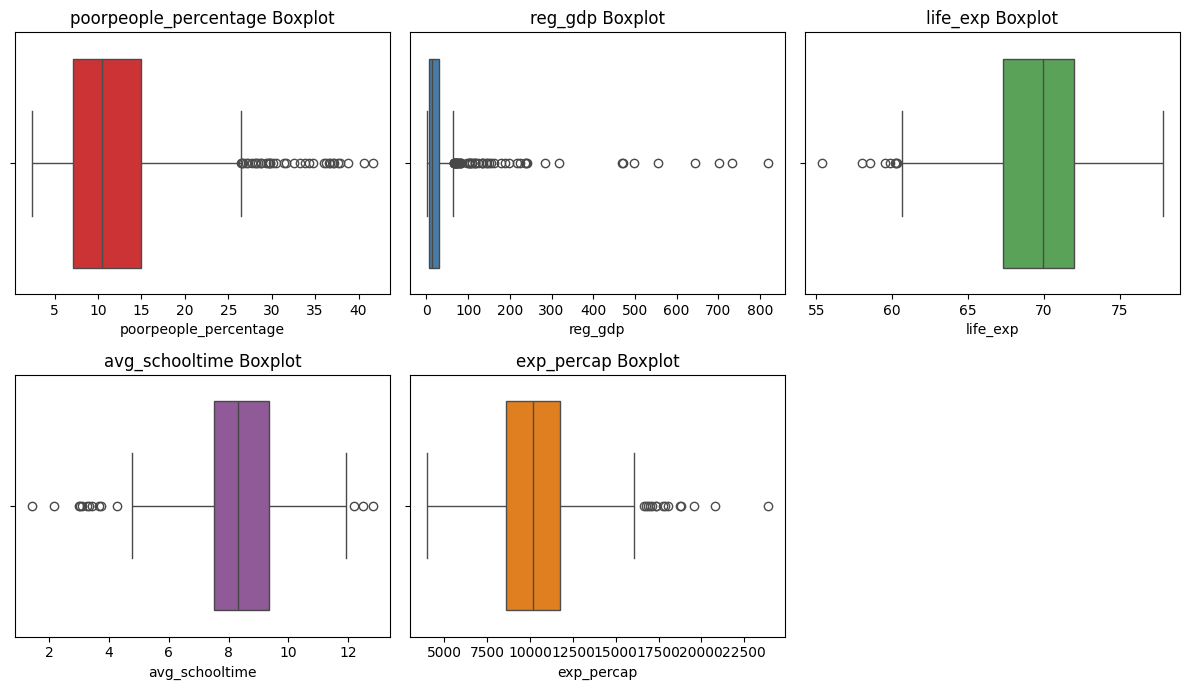

In [521]:
# Boxplot Visualization
col_box = ['poorpeople_percentage', 'reg_gdp', 'life_exp', 'avg_schooltime', 'exp_percap']
color_palette = sns.color_palette("Set1", len(col_box))
plt.figure(figsize = (12, 7))

for i, column in enumerate(col_box, 1):
    plt.subplot((len(col_box)//3)+1, 3, i)
    sns.boxplot(data=df, x=column, color=color_palette[i - 1])    
    plt.xlabel(column)
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()

In [522]:
# jumlah kota / kabupaten setiap provinsi
province_counts = df['province'].value_counts().reset_index()
province_counts

,province,count
0,Jawa Timur,38
1,Jawa Tengah,35
2,Sumatera Utara,33
3,Papua,29
4,Jawa Barat,27
5,Sulawesi Selatan,24
6,Aceh,23
7,Nusa Tenggara Timur,22
8,Sumatera Barat,19
9,Sulawesi Tenggara,17


/tmp/ipykernel_7624/2507046781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_counts.index, y=province_counts.values, palette='Set1')


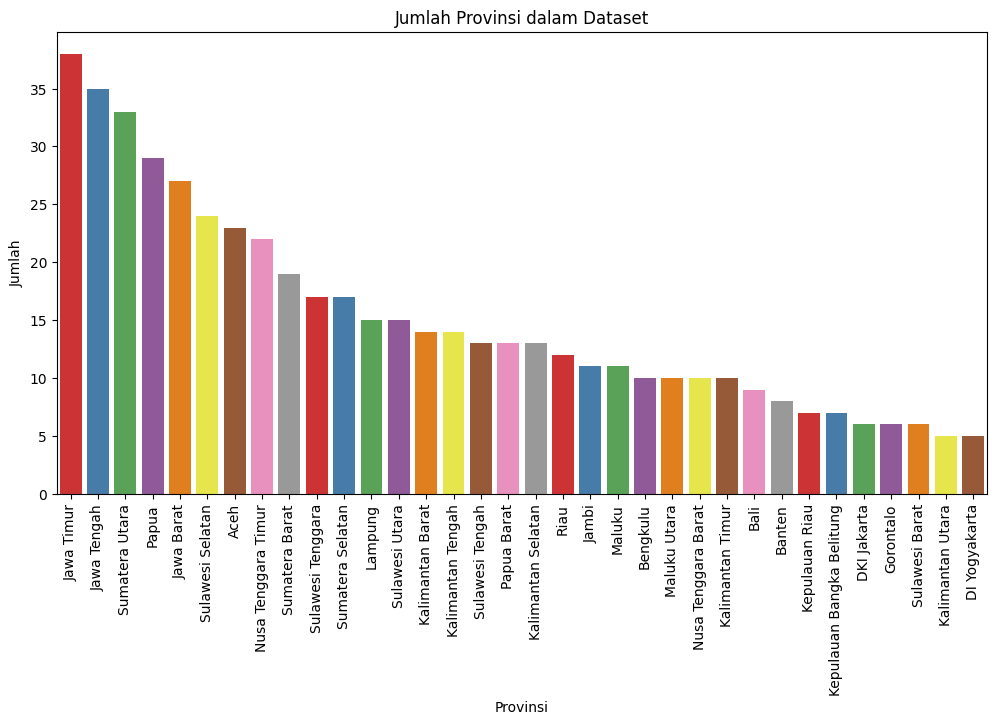

In [523]:
# Kita plot kedalam histogram
# Menghitung frekuensi kemunculan setiap provinsi
province_counts = df['province'].value_counts()

# Membuat bar plot untuk jumlah provinsi
plt.figure(figsize=(12, 6))
sns.barplot(x=province_counts.index, y=province_counts.values, palette='Set1')
plt.xticks(rotation=90)  # Memutar label agar tidak tumpang tindih
plt.title('Jumlah Provinsi dalam Dataset')
plt.xlabel('Provinsi')
plt.ylabel('Jumlah')
plt.show()


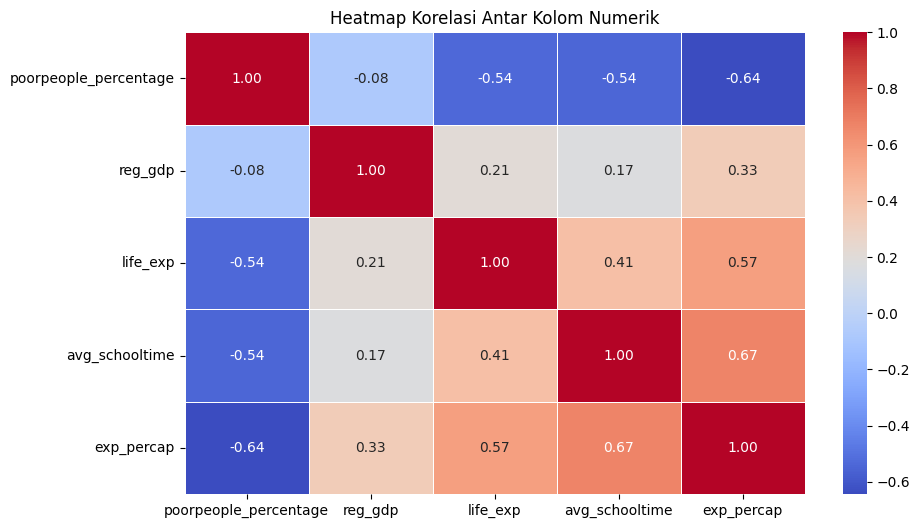

In [524]:
# Menghitung korelasi antar kolom numerik
correlation_matrix = df[['poorpeople_percentage', 'reg_gdp', 'life_exp', 'avg_schooltime', 'exp_percap']].corr()

# Membuat heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Heatmap Korelasi Antar Kolom Numerik')
plt.show()


Sepertinya penghapusan coloumn tidak diperlukan karena setiap coloumn cukup memiliki korelasi antar coloumn

Explained variance ratio (komponen utama 1 dan 2): [0.55691782 0.19207116]
Total variance yang dijelaskan: 0.75


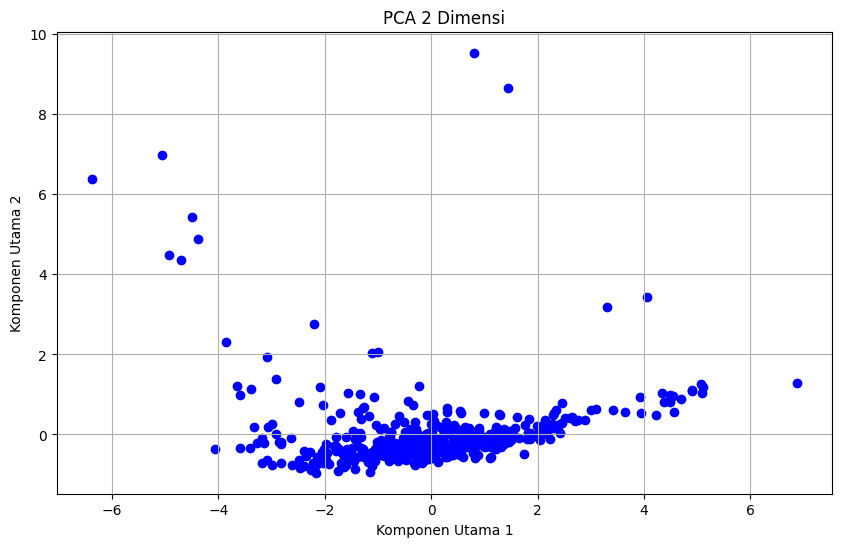

In [525]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Misalkan df adalah DataFrame yang sudah di-load
X = df[['poorpeople_percentage', 'reg_gdp','life_exp', 'avg_schooltime', 'exp_percap']]

# 1. Standarisasi data (penting untuk PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Lakukan PCA untuk mengurangi dimensi menjadi 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Menampilkan rasio variansi yang dijelaskan oleh dua komponen pertama
print(f"Explained variance ratio (komponen utama 1 dan 2): {pca.explained_variance_ratio_}")
print(f"Total variance yang dijelaskan: {sum(pca.explained_variance_ratio_):.2f}")

# 4. Visualisasi hasil PCA dalam 2 dimensi
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', marker='o')
plt.title('PCA 2 Dimensi')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.grid(True)
plt.show()


# K-Means

In [526]:
pca_data = X_pca

In [527]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(pca_data)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(pca_data, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [1171.2463168768018]
silhoutte score for n_clusters = 2 is 0.4157490275796184
wcss score for n_cluster = 3 is [1171.2463168768018, 795.7699228278418]
silhoutte score for n_clusters = 3 is 0.4907394199265124
wcss score for n_cluster = 4 is [1171.2463168768018, 795.7699228278418, 489.5712451955316]
silhoutte score for n_clusters = 4 is 0.48360564935078215
wcss score for n_cluster = 5 is [1171.2463168768018, 795.7699228278418, 489.5712451955316, 358.78471425360885]
silhoutte score for n_clusters = 5 is 0.4626687267069922
wcss score for n_cluster = 6 is [1171.2463168768018, 795.7699228278418, 489.5712451955316, 358.78471425360885, 282.4689886803674]
silhoutte score for n_clusters = 6 is 0.46745202490290927
wcss score for n_cluster = 7 is [1171.2463168768018, 795.7699228278418, 489.5712451955316, 358.78471425360885, 282.4689886803674, 216.75335048488986]
silhoutte score for n_clusters = 7 is 0.44168125408178677
wcss score for n_cluster = 8 is [1171.2463168768

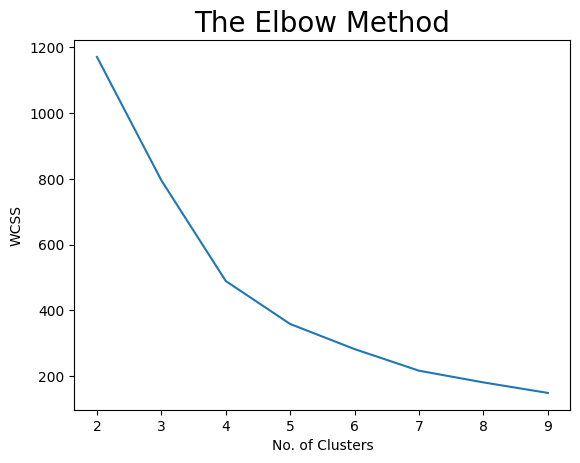

In [528]:
# Visualizing Elbow Method
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

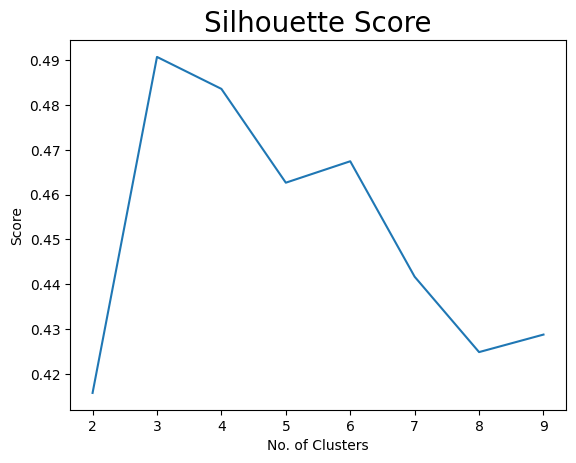

In [529]:
# Visualizing Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

In [530]:
# dari silhouette method saya akan menggunakan 3 cluster
kmeansmodel = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 500, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(pca_data)

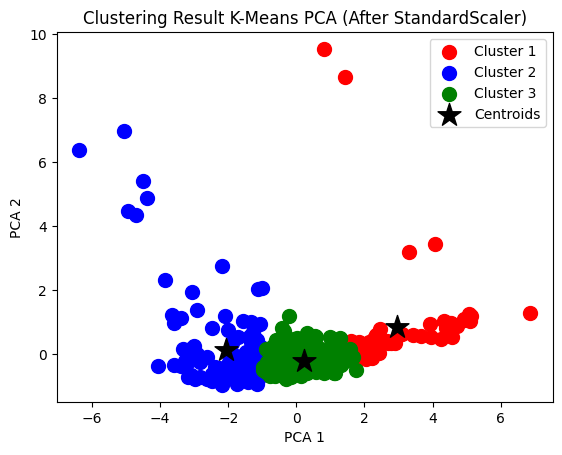

In [531]:
# Menambahkan label klaster ke DataFrame df asli
df['Cluster_Kmeans'] = y_kmeans  # Menambahkan kolom 'Cluster' yang berisi label klaster

# Cluster visualization using scatter plot
plt.scatter(pca_data[y_kmeans == 0, 0], pca_data[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(pca_data[y_kmeans == 1, 0], pca_data[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(pca_data[y_kmeans == 2, 0], pca_data[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')

# Display the cluster center
plt.scatter(kmeansmodel.cluster_centers_[:, 0], kmeansmodel.cluster_centers_[:, 1], s = 300, c = 'black', label = 'Centroids', marker = '*')
plt.title('Clustering Result K-Means PCA (After StandardScaler)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [532]:

cluster_1_Kmeans = df[df['Cluster_Kmeans'] == 0] 
cluster_2_Kmeans = df[df['Cluster_Kmeans'] == 1] 
cluster_3_Kmeans = df[df['Cluster_Kmeans'] == 2] 


In [533]:
cluster_1_Kmeans.describe()

,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans
count,60.000000,60.000000,60.00000,60.000000,60.000000,60.0
mean,27.887000,38.000250,64.89500,6.396833,6569.200000,0.0
std,6.816358,144.255402,3.15379,1.953481,1437.617672,0.0
min,14.840000,1.042000,55.37000,1.420000,3976.000000,0.0
25%,23.632500,1.784250,63.26875,5.110000,5414.250000,0.0
50%,27.930000,3.041000,65.39250,6.755000,6345.000000,0.0
75%,32.762500,6.121250,67.06125,7.870000,7442.250000,0.0
max,41.660000,819.000000,70.16500,9.690000,9708.000000,0.0


In [534]:
cluster_2_Kmeans.describe()

,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.0
mean,6.943821,78.177585,72.841016,10.301138,13590.878049,1.0
std,2.877310,126.852337,2.016737,1.141913,2381.087730,0.0
min,2.380000,3.473000,66.645000,7.250000,10195.000000,1.0
25%,4.880000,13.367000,71.312500,9.550000,11834.500000,1.0
50%,6.640000,32.211000,72.595000,10.500000,13117.000000,1.0
75%,8.430000,82.246000,74.057500,11.100000,14783.000000,1.0
max,17.890000,701.980000,77.855000,12.830000,23888.000000,1.0


In [535]:
cluster_3_Kmeans.describe()


,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans
count,331.000000,331.000000,331.000000,331.000000,331.000000,331.0
mean,11.423233,18.098142,69.278127,8.113505,9791.876133,2.0
std,4.413465,18.895492,2.690918,0.901787,1478.569015,0.0
min,2.750000,1.211000,61.700000,5.920000,6378.000000,2.0
25%,7.825000,5.775000,67.412500,7.485000,8716.000000,2.0
50%,11.300000,11.418000,69.235000,8.080000,9851.000000,2.0
75%,14.115000,22.782000,71.155000,8.710000,10856.000000,2.0
max,26.090000,145.592000,76.285000,11.180000,14711.000000,2.0


### Kesimpulan

Dari clustering tadi kita bisa mengetahui beberapa daerah yang lebih baik untuk ditempati yaitu pada cluster-2 sedangkan cluster-1 adalah daerah yang paling kurang baik untuk ditempati.

# Hierarchical Clustering (Agglomerative Clustering)

In [536]:
pca_data = X_pca

In [537]:
from sklearn.cluster import AgglomerativeClustering
linkage_col = ['ward', 'complete', 'average', 'single']
scores_all = [[] for _ in range(len(linkage_col))]

for j in range (len(linkage_col)):
    print('Linkage: ', linkage_col[j])
    scores = []
    for i in range(2, 10):
        AC = AgglomerativeClustering(n_clusters=i, linkage = linkage_col[j])
        AC.fit(pca_data)
        
        labels = AC.labels_
        silhouette_avg = silhouette_score(pca_data, labels)
        scores.append(silhouette_avg)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))
    print("\n##########################\n")
    scores_all[j] = scores

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.4293696214198594
silhoutte score for n_clusters = 3 is 0.468110214372428
silhoutte score for n_clusters = 4 is 0.4397877547948898
silhoutte score for n_clusters = 5 is 0.46294452100281125
silhoutte score for n_clusters = 6 is 0.46774064174515995
silhoutte score for n_clusters = 7 is 0.4228243916471338
silhoutte score for n_clusters = 8 is 0.40603557995262307
silhoutte score for n_clusters = 9 is 0.3791953696541056

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.7617672817121116
silhoutte score for n_clusters = 3 is 0.6377944021306137
silhoutte score for n_clusters = 4 is 0.6356981109575183
silhoutte score for n_clusters = 5 is 0.4875546079518023
silhoutte score for n_clusters = 6 is 0.45854614391131776
silhoutte score for n_clusters = 7 is 0.45443608495520116
silhoutte score for n_clusters = 8 is 0.4443395864183079
silhoutte score for n_clusters = 9 is 0.4010808444045454

####################

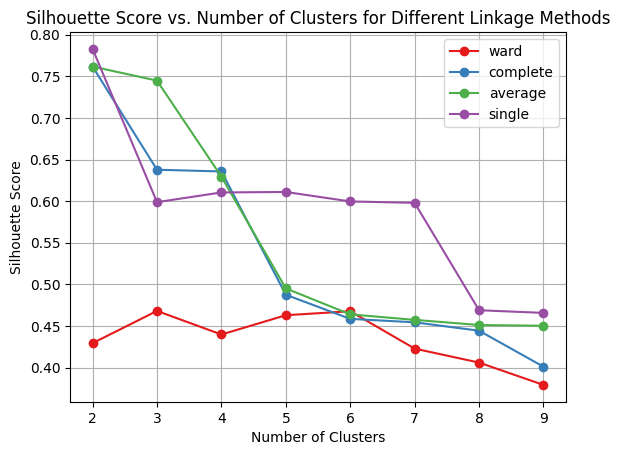

In [538]:
colors = sns.color_palette("Set1", len(linkage_col))

for j in range(len(linkage_col)):
    plt.plot(range(2, 10), scores_all[j], marker='o', color=colors[j], label=linkage_col[j])

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters for Different Linkage Methods')
plt.legend()
plt.grid(True)
plt.show()

### SINGLE LINK

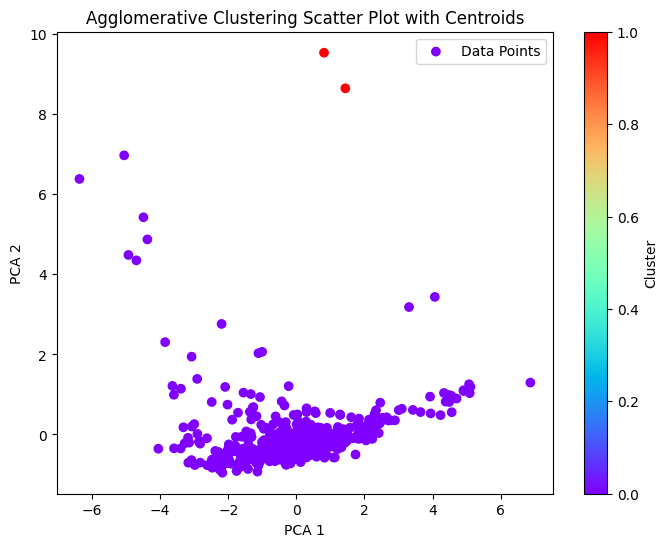

In [539]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['poorpeople_percentage','reg_gdp' ,'life_exp', 'avg_schooltime', 'exp_percap']])

# Reduksi data ke 2 dimensi menggunakan PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Melakukan klasterisasi menggunakan Agglomerative Clustering
n_cluster = 2
AC = AgglomerativeClustering(n_clusters=n_cluster, linkage='single')
labels = AC.fit_predict(pca_data)

# Menambahkan hasil klasterisasi ke DataFrame
df['cluster_single'] = labels  # Menambahkan kolom 'Cluster' yang berisi label klaster

# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='rainbow', label='Data Points')
plt.title('Agglomerative Clustering Scatter Plot with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

### WARD

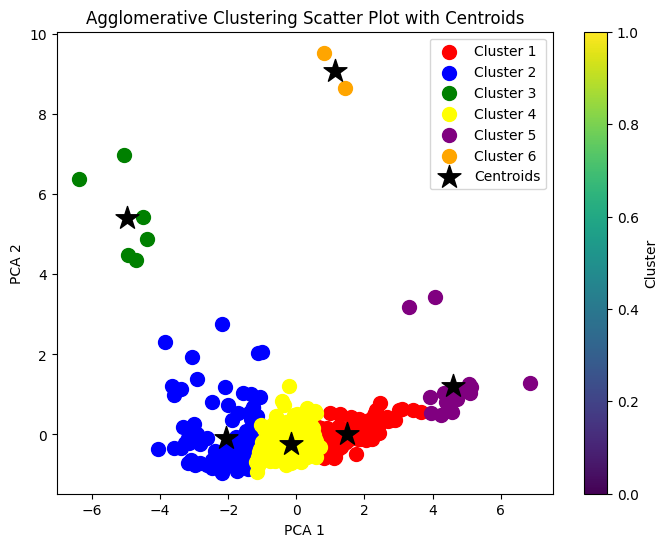

In [540]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from matplotlib.lines import Line2D  # Untuk menambahkan custom legend

# Misalkan pca_data adalah data yang sudah diproses dengan PCA
n_cluster = 6
AC = AgglomerativeClustering(n_clusters=n_cluster, linkage='ward')
labels = AC.fit_predict(pca_data)

# Menambahkan kolom cluster ke DataFrame df
df['cluster_ward'] = labels

# Menyiapkan data untuk centroid per klaster
df_train_with_labels = np.column_stack((pca_data, labels))

centroids = []
for cluster_label in range(n_cluster):  
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    cluster_centroid = np.mean(cluster_data[:, :-1], axis=0)
    centroids.append(cluster_centroid)

centroids = np.array(centroids)

# Membuat visualisasi scatter plot dengan centroid
plt.figure(figsize=(8, 6))

plt.scatter(pca_data[labels == 0, 0], pca_data[labels == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(pca_data[labels == 1, 0], pca_data[labels == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(pca_data[labels == 2, 0], pca_data[labels == 2, 1], s = 100, c = 'green', label = 'Cluster 3')

plt.scatter(pca_data[labels == 3, 0], pca_data[labels == 3, 1], s = 100, c = 'yellow', label = 'Cluster 4')
plt.scatter(pca_data[labels == 4, 0], pca_data[labels == 4, 1], s = 100, c = 'purple', label = 'Cluster 5')
plt.scatter(pca_data[labels == 5, 0], pca_data[labels == 5, 1], s = 100, c = 'orange', label = 'Cluster 6')

plt.scatter(centroids[:, 0], centroids[:, 1], s = 300, c = 'black', label = 'Centroids', marker = '*')


plt.title('Agglomerative Clustering Scatter Plot with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.legend()


# Menampilkan plot
plt.show()


<!--  -->

In [541]:
import scipy.cluster.hierarchy as sch
linked = sch.linkage(pca_data, 'ward')

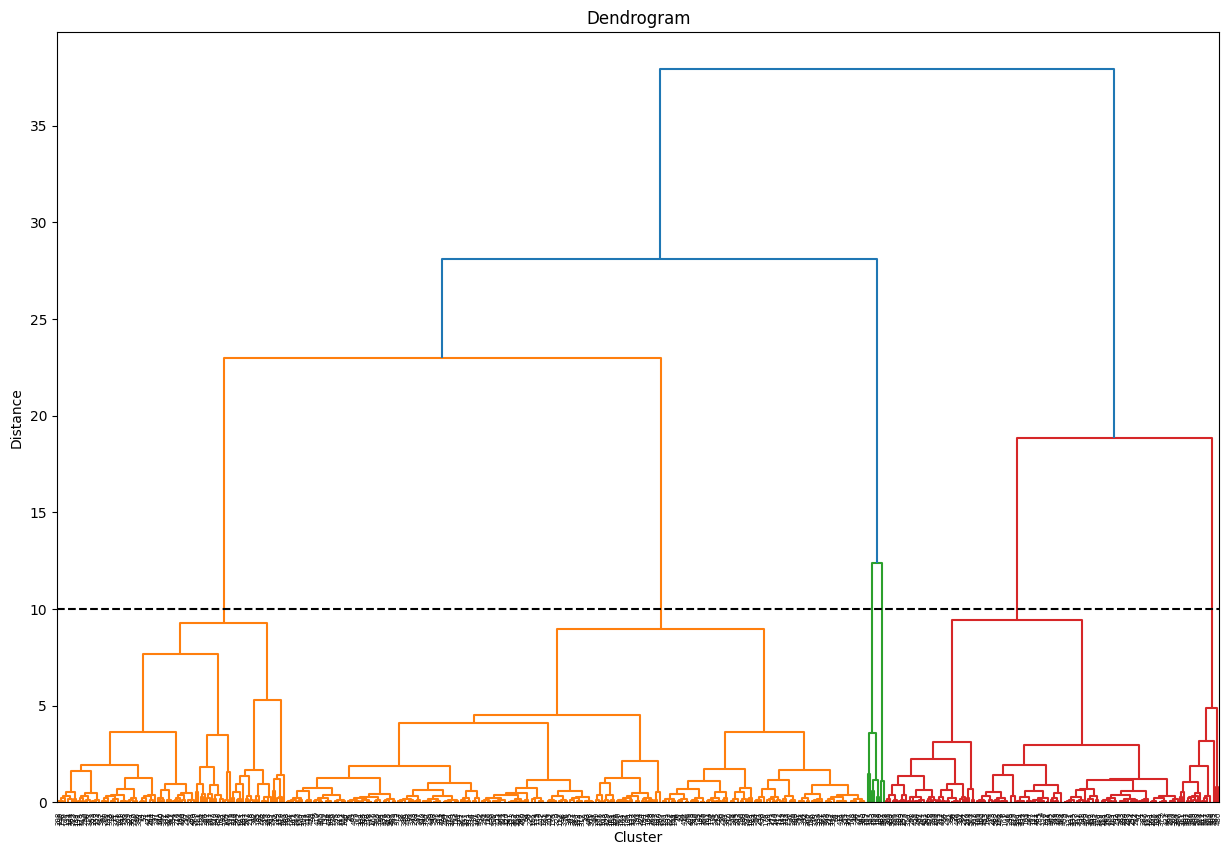

In [542]:
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linked, orientation='top',distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.axhline(y=10, color='black', linestyle='--') # at this point, will divide the data into 2 clusters
plt.show()

In [543]:
# Menampilkan data yang berada di klaster 1
cluster_1_data = df[df['cluster_ward'] == 0].reset_index()

# Menampilkan data yang berada di klaster 2
cluster_2_data = df[df['cluster_ward'] == 1].reset_index()

# Menampilkan data yang berada di klaster 3
cluster_3_data = df[df['cluster_ward'] == 2].reset_index()

# Menampilkan data yang berada di klaster 1
cluster_4_data = df[df['cluster_ward'] == 3].reset_index()

# Menampilkan data yang berada di klaster 2
cluster_5_data = df[df['cluster_ward'] == 4].reset_index()

# Menampilkan data yang berada di klaster 3
cluster_6_data = df[df['cluster_ward'] == 5].reset_index()



In [544]:
cluster_1_data.describe()

,index,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans,cluster_single,cluster_ward
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.0,130.0
mean,293.915385,18.043615,9.238831,66.408077,7.752923,8239.461538,1.384615,0.0,0.0
std,161.102405,6.312523,9.670021,2.388327,1.067376,1341.250170,0.926648,0.0,0.0
min,0.000000,5.190000,1.042000,59.560000,4.860000,5415.000000,0.000000,0.0,0.0
25%,133.500000,13.895000,2.997750,65.031250,7.080000,7330.500000,0.000000,0.0,0.0
50%,301.500000,16.665000,4.803500,66.467500,7.795000,8165.500000,2.000000,0.0,0.0
75%,451.750000,22.702500,11.644500,68.070000,8.455000,9138.250000,2.000000,0.0,0.0
max,510.000000,37.910000,47.523000,73.555000,10.530000,11938.000000,2.000000,0.0,0.0


In [545]:
cluster_2_data.describe()

,index,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans,cluster_single,cluster_ward
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.0,101.0,101.0
mean,230.475248,6.890891,58.856158,72.932871,10.391881,13567.603960,1.0,0.0,1.0
std,123.185193,2.871167,66.914701,2.022476,1.070200,1935.297037,0.0,0.0,0.0
min,18.000000,2.570000,3.473000,66.645000,7.780000,10307.000000,1.0,0.0,1.0
25%,146.000000,4.850000,13.920000,71.385000,9.570000,12168.000000,1.0,0.0,1.0
50%,221.000000,6.420000,32.211000,72.620000,10.570000,13280.000000,1.0,0.0,1.0
75%,328.000000,8.520000,81.941000,73.995000,11.150000,14704.000000,1.0,0.0,1.0
max,513.000000,17.890000,317.943000,77.855000,12.830000,19598.000000,1.0,0.0,1.0


In [546]:
cluster_3_data.describe()

,index,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans,cluster_single,cluster_ward
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.0,6.0,6.0
mean,174.666667,4.926667,556.546000,73.994167,11.131667,19401.833333,1.0,0.0,2.0
std,43.297421,1.273572,97.197584,0.422012,0.498213,2521.805973,0.0,0.0,0.0
min,155.000000,3.560000,469.918000,73.330000,10.500000,17365.000000,1.0,0.0,2.0
25%,156.250000,4.287500,477.573250,73.771250,10.787500,17765.250000,1.0,0.0,2.0
50%,157.500000,4.625000,525.904000,74.135000,11.100000,18312.000000,1.0,0.0,2.0
75%,158.750000,5.157500,622.056250,74.206250,11.577500,20291.250000,1.0,0.0,2.0
max,263.000000,7.240000,701.980000,74.485000,11.670000,23888.000000,1.0,0.0,2.0


In [547]:
cluster_4_data.describe()

,index,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans,cluster_single,cluster_ward
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.0,257.0
mean,231.704280,9.919805,20.848191,70.303716,8.271206,10293.797665,1.937743,0.0,3.0
std,138.164269,3.662023,20.349849,2.293973,0.926516,1377.778635,0.242093,0.0,0.0
min,3.000000,2.380000,1.211000,63.425000,6.330000,7064.000000,1.000000,0.0,3.0
25%,112.000000,7.180000,7.856000,68.790000,7.560000,9409.000000,2.000000,0.0,3.0
50%,227.000000,9.680000,13.944000,70.285000,8.160000,10290.000000,2.000000,0.0,3.0
75%,352.000000,12.530000,26.957000,71.615000,8.810000,11322.000000,2.000000,0.0,3.0
max,493.000000,20.560000,145.592000,76.285000,11.180000,14711.000000,2.000000,0.0,3.0


In [548]:
cluster_5_data.describe()


,index,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans,cluster_single,cluster_ward
count,18.000000,18.000000,18.000000,18.00000,18.000000,18.000000,18.0,18.0,18.0
mean,488.611111,34.839444,27.364556,63.33750,4.048889,5156.444444,0.0,0.0,4.0
std,45.362772,4.270376,73.281053,3.56226,1.380673,811.250032,0.0,0.0,0.0
min,311.000000,24.830000,1.215000,55.37000,1.420000,3976.000000,0.0,0.0,4.0
25%,491.250000,32.762500,1.398750,60.30500,3.130000,4666.250000,0.0,0.0,4.0
50%,498.500000,36.130000,1.699000,65.34500,3.695000,4956.000000,0.0,0.0,4.0
75%,506.750000,37.157500,2.555500,65.96500,5.110000,5391.000000,0.0,0.0,4.0
max,512.000000,41.660000,239.000000,67.26000,6.660000,7545.000000,0.0,0.0,4.0


In [549]:
cluster_6_data.describe()

,index,poorpeople_percentage,reg_gdp,life_exp,avg_schooltime,exp_percap,Cluster_Kmeans,cluster_single,cluster_ward
count,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.0,2.0,2.0
mean,481.500000,30.345000,775.50000,66.420000,6.795000,5375.000000,0.0,1.0,5.0
std,0.707107,1.477853,61.51829,1.668772,0.233345,183.847763,0.0,0.0,0.0
min,481.000000,29.300000,732.00000,65.240000,6.630000,5245.000000,0.0,1.0,5.0
25%,481.250000,29.822500,753.75000,65.830000,6.712500,5310.000000,0.0,1.0,5.0
50%,481.500000,30.345000,775.50000,66.420000,6.795000,5375.000000,0.0,1.0,5.0
75%,481.750000,30.867500,797.25000,67.010000,6.877500,5440.000000,0.0,1.0,5.0
max,482.000000,31.390000,819.00000,67.600000,6.960000,5505.000000,0.0,1.0,5.0


### Kenapa tidak Single Link saja bukan Ward?


Dataset yang saya miliki persebaranya sangat luas setelah melakukan PCA, Ward cenderung menjaga klaster agar lebih kompak dengan meminimalkan variansi dalam setiap klaster yang terbentuk. Dengan demikian, Ward menghasilkan klaster yang lebih homogen dan terisolasi, tetapi terkadang kurang fleksibel dalam menggabungkan titik yang lebih berjauhan.
<br><br>
Dengan demikian, ward baik menjelaskan kebutuhan saya. karena tujuan saya ingin mencari tempat yang nyaman untuk ditinggali dan juga memiliki GDP lebih Tinggi. Dari analysist klasifikasi ward, saya bisa mengetahui daerah mana yang nyaman ditinggali dan mendapat fasilitas layak (infrastruktur dan pendidikan) tetapi memiliki GDP lebih tinggi, dimana GDP sangat berpengaruh terhadap peningkatan pendapatan regional dan kesejahteraan atau mungkin sebagai ladang investasi.
<br>

### KESIMPULAN

Setelah melakukan klasifikasi ward, saya memiliki kesimpulan bahwa cluster-3 adalah daerah yang paling sejahtera dan terbaik untuk ditempati maupun melakukan investasi secara bersamaan. Untuk cluster-2 sama hidup disana hampir sama sejahteranya dengan daerah pada cluster-3 tetapi buruk dalam GDP (buruk untuk ladang investasi). Untuk cluster-1 dan cluster-4 sudah mendekati tidak sejahtera, angka ekspektasi hidup sedikit lebih rendah dan tidak baik dijadikan ladang investasi. Untuk cluster-5 adalah daerah yang paling kurang fasilitas pendidikan, angka ekspektasi kehidupan rendah dan kemiskinan yang tinggi. Untuk cluster-6 adalah daerah yang baik untuk investasi tetapi tidak memiliki fasilitas(pendidikan, kesehatan) dan kesejahteraan rakyat yang baik. 

Dari data diatas, Saya juga bisa mengambil kesimpulan pada cluster-6, GDP terbesar ada disini namun rakyatnya tidak hidup sejahtera. Data ini makin miris karena ini berarti banyak investasi dari luar daerah(cluster-6) tersebut yang menghasilkan jasa dan barang yang mahal dimata dunia tetapi tidak melibatkan rakyat daerah itu sendiri. 